In [2]:
from os.path import join 

import matplotlib.pyplot as plt 
import numpy as np 
import tidy3d as td 
from tidy3d import web 
from tidy3d.plugins.resonance import ResonanceFinder

In [3]:
web.test()

14:24:40 Pacific Daylight Time Authentication configured successfully!

In [5]:
holes_file = np.loadtxt(join("misc", "optimized_L3_holes.txt"))
xs, ys, rs = holes_file.T

In [6]:
# Periodicity in units of PhC periods in x and y directions
nx, ny = 32, 32

# Lattice constant of the PhC in micron
alattice = 0.4

# Regular PhC lattice parameters
r_hole = 0.1  # radius of holes in regular PhC region
d_slab = 0.22  # slab thickness
n_slab = 3.4757  # refractive index of the slab

# Materials - air and silicon
air = td.Medium()
si = td.Medium(permittivity=n_slab**2)

# Simulation domain size (micron)
size_z = 6
sim_size = [(nx + 1) * alattice, (ny + 1) * alattice * np.sqrt(3) / 2, size_z]

In [7]:
# Initialize structures
slab = td.Structure(geometry=td.Box(center=[0, 0, 0], size=[td.inf, td.inf, d_slab]), medium=si)

holes_group = []
# Add all provided optimized holes
for x, y, r in zip(xs, ys, rs):
    holes_group.append(td.Cylinder(center=[x, y, 0], radius=r, length=d_slab))

# Pad with regular PhC holes outside of the optimized region
xmax_opt = np.amax(np.int64(xs / alattice))
ymax_opt = np.amax(np.int64(ys / alattice * 2 / np.sqrt(3)))
nx_pos, ny_pos = nx // 2 + 1, ny // 2 + 1
for iy in range(ny_pos):
    for ix in range(nx_pos):
        if ix > xmax_opt or iy > ymax_opt:
            xp = ix + (iy % 2) * 0.5
            yp = iy * np.sqrt(3) / 2
            holes_group.append(td.Cylinder(center=[xp, yp, 0], radius=r_hole, length=d_slab))

holes = td.Structure(geometry=td.GeometryGroup(geometries=holes_group), medium=air)

## Initialize source

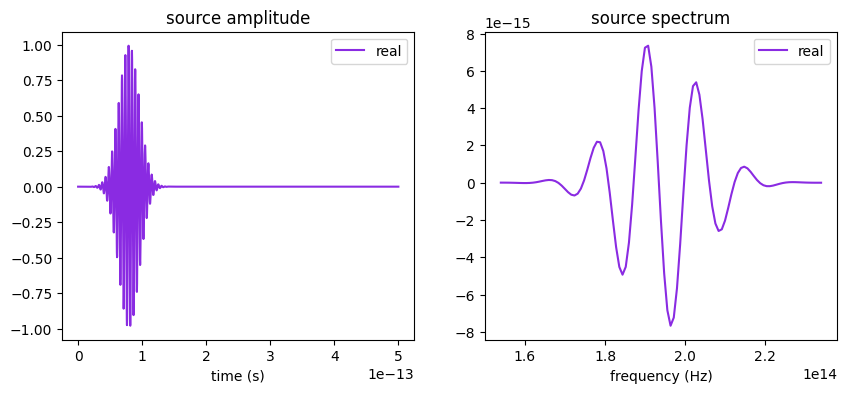

In [8]:
# Central frequency around which we'll look for the cavity mode (Hz)
wavelength = 1.55
freq0 = td.C_0 / wavelength

# Source bandwidth (Hz)
fwidth = 1e13

# Simulation run time (s)
run_time = 10e-12

# Source; plot time dependence to verify when the source pulse decayed
source = td.PointDipole(
    center=(0, 0, 0),
    source_time=td.GaussianPulse(freq0=freq0, fwidth=fwidth),
    polarization="Ey",
)

# Source pulse is much shorter than the simulation run_time defined above,
# so we only examine the signal up to a shorter time = 5e-13fs
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
source.source_time.plot(np.linspace(0, 5e-13, 2000), ax=ax[0])
source.source_time.plot_spectrum(times=np.linspace(0, 5e-13, 2000), ax=ax[1])
plt.show()

## Initialize monitors

In [18]:
# Starting time after the source has decayed for time series and
# for apodization of frequency domain monitors
t_start = 4e-13

# Time series monitor for Q-factor computation
time_series_mnt = td.FieldTimeMonitor(
    center=[0, 0, 0], size=[0, 0, 0], start=t_start, name="time_series"
)

# Apodization to exclude the source pulse from the frequency-domain monitors
apodization = td.ApodizationSpec(start=t_start, width=2e-13)

# near field
field_mnt = td.FieldMonitor(
    center=[0, 0, 0],
    size=[4, 2 * np.sqrt(3), 0],
    freqs=[freq0],
    name="field",
    apodization=apodization,
)

# far field
ux = np.linspace(-1, 1, 101)
uy = np.linspace(-1, 1, 101)
far_field_mnt = td.FieldProjectionKSpaceMonitor(
    center=(0, 0, d_slab / 2 + 0.1),
    size=(td.inf, td.inf, 0),
    freqs=[freq0],
    name="n2f_monitor",
    proj_axis=2,
    ux=ux,
    uy=uy,
    apodization=apodization,
)

In [25]:
td.config.logging_level = "ERROR"

steps_per_unit_length = 20
grid_spec = td.GridSpec(
    grid_x=td.UniformGrid(dl=alattice / steps_per_unit_length),
    grid_y=td.UniformGrid(dl=alattice / steps_per_unit_length * np.sqrt(3) / 2),
    grid_z=td.AutoGrid(min_steps_per_wvl=steps_per_unit_length),
)

# Simulation
sim = td.Simulation(
    size=sim_size,
    grid_spec=grid_spec,
    structures=[slab, holes],
    sources=[source],
    monitors=[time_series_mnt, field_mnt, far_field_mnt],
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
    symmetry=(1, -1, 1),
    shutoff=0,
)

print(f"Total number of grid points (millions): {sim.num_cells / 1e6:1.4f}")
print(f"Total number of time steps: {sim.num_time_steps}")

Total number of grid points (millions): 53.3356
Total number of time steps: 269145


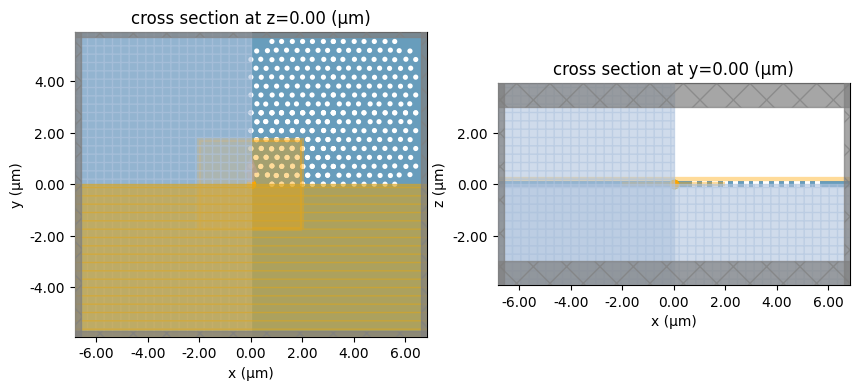

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sim.plot(z=0, ax=ax[0])
sim.plot(y=0, ax=ax[1])
plt.show()

In [ ]:
import datetime

job = web.Job(simulation=sim, task_name="L3_opt", verbose=True)
sim_data = job.run(path="data/sim.hdf5")

# Log task_id to file
task_id = job.task_id
timestamp = datetime.datetime.now().isoformat()
log_entry = f"{timestamp}\ttask_name=L3_opt\ttask_id={task_id}\n"
with open("data/task_log.txt", "a") as f:
    f.write(log_entry)
print(log_entry.strip())


15:39:00 Pacific Daylight Time Created task 'L3_opt' with resource_id           
                               'fdve-8549f413-db7f-45ff-bece-2a7de580782e' and  
                               task_type 'FDTD'.

                               View task using web UI at                        
                               ]8;id=835656;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8549f413-db7f-45ff-bece-2a7de580782e\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=21234;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8549f413-db7f-45ff-bece-2a7de580782e\taskId]8;;\
                               ]8;id=835656;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8549f413-db7f-45ff-bece-2a7de580782e\=]8;;\]8;id=368533;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8549f413-db7f-45ff-bece-2a7de580782e\fdve]8;;\]8;id=835656;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8549f413-db7f-45ff-bece-2a7de580782e\-8549f413-db7f-45ff-bece-2a7de580782e']8;;\.

                               Task folder: ]8;id=918882;https://tidy3d.simulation.cloud/folders/folder-401c0a0c-8e13-4a51-9b19-e6b8ae1b963e\'default']8;;\.

c:\Users\xtliang\Documents\01-Projects\20260304-twisted\.venv\Lib\site-packages\
rich\live.py:231: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

15:39:04 Pacific Daylight Time Estimated FlexCredit cost: 0.565. Minimum cost   
                               depends on task execution details. Use           
                               'web.real_cost(task_id)' to get the billed       
                               FlexCredit cost after a simulation run.

...

15:39:50 Pacific Daylight Time running solver

15:41:15 Pacific Daylight Time status = postprocess

15:41:16 Pacific Daylight Time status = success

15:41:18 Pacific Daylight Time View simulation result at                        
                               ]8;id=774504;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8549f413-db7f-45ff-bece-2a7de580782e\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=695428;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8549f413-db7f-45ff-bece-2a7de580782e\taskId]8;;\
                               ]8;id=774504;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8549f413-db7f-45ff-bece-2a7de580782e\=]8;;\]8;id=435408;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8549f413-db7f-45ff-bece-2a7de580782e\fdve]8;;\]8;id=774504;https://tidy3d.simulation.cloud/workbench?taskId=fdve-8549f413-db7f-45ff-bece-2a7de580782e\-8549f413-db7f-45ff-bece-2a7de580782e']8;;\.

15:41:23 Pacific Daylight Time Loading simulation from data\sim.hdf5

In [32]:
print(sim_data.log)

[22:39:45] WARNING: Structure: simulation.structures[1] (no `name` was          
           specified) was detected as being less than half of a central         
           wavelength from a PML on side x-max. To avoid inaccurate results or  
           divergence, please increase gap between any structures and PML or    
           fully extend structure through the pml.                              
           INFO: Auto meshing using wavelength 1.5500 defined from sources.     
           INFO: Auto meshing using wavelength 1.5500 defined from sources.     
           INFO: Auto meshing using wavelength 1.5500 defined from sources.     
[22:39:46] USER: Simulation domain Nx, Ny, Nz: [684, 684, 114]                  
           USER: Applied symmetries: (1, -1, 1)                                 
           USER: Number of computational grid points: 6.9818e+06.               
           USER: Subpixel averaging method: SubpixelSpec(attrs={},              
           dielectric=Polari

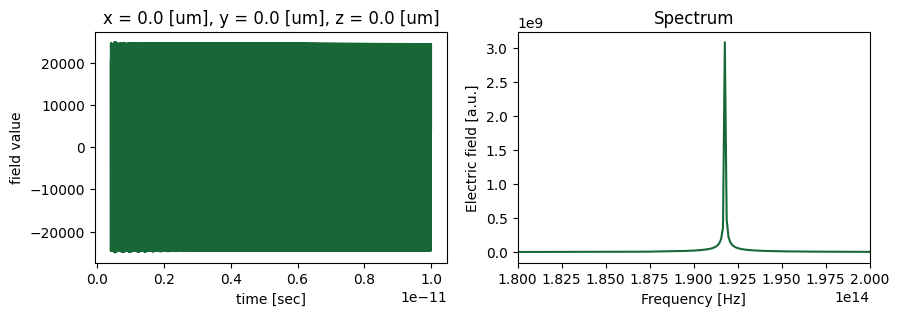

In [29]:
# Get data from the TimeMonitor
tdata = sim_data["time_series"]

time_series = tdata.Ey.squeeze()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plot time dependence
time_series.plot(ax=ax1)

# Make frequency mesh and plot spectrum
dt = sim_data.simulation.dt
fmesh = np.linspace(-1 / dt / 2, 1 / dt / 2, time_series.size)
spectrum = np.fft.fftshift(np.fft.fft(time_series))

ax2.plot(fmesh, np.abs(spectrum))
ax2.set_xlim(1.8e14, 2e14)
ax2.set_xlabel("Frequency [Hz]")
ax2.set_ylabel("Electric field [a.u.]")
ax2.set_title("Spectrum")
plt.show()

In [30]:
resonance_finder = ResonanceFinder(freq_window=(1.8e14, 2e14), init_num_freqs=100)
resonance_data = resonance_finder.run(sim_data["time_series"])
resonance_data.to_dataframe()

,decay,Q,amplitude,phase,error
freq,,,,,
1.917840e+14,6.762763e+08,890918.549411,12317.411927,-0.598404,0.000419


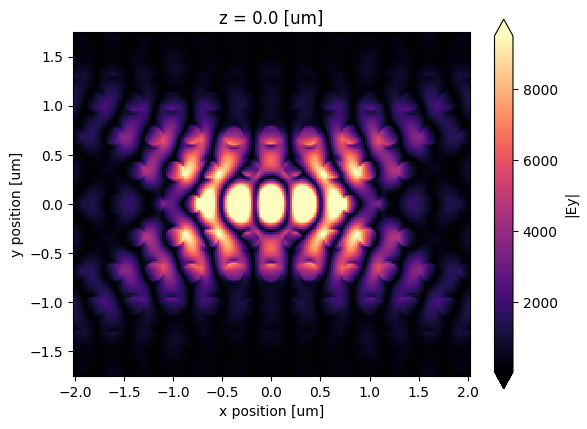

In [31]:
fig, ax = plt.subplots(1)
sim_data.plot_field("field", "Ey", val="abs", z=0, ax=ax, eps_alpha=0)
plt.show()